In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
# Load the dataset
df = pd.read_csv('/Users/nooriya/Downloads/world_population.csv')
print(df.shape)
print(df.head())

(234, 17)
   Rank CCA3 Country/Territory           Capital Continent  2022 Population  \
0    36  AFG       Afghanistan             Kabul      Asia         41128771   
1   138  ALB           Albania            Tirana    Europe          2842321   
2    34  DZA           Algeria           Algiers    Africa         44903225   
3   213  ASM    American Samoa         Pago Pago   Oceania            44273   
4   203  AND           Andorra  Andorra la Vella    Europe            79824   

   2020 Population  2015 Population  2010 Population  2000 Population  \
0         38972230         33753499         28189672         19542982   
1          2866849          2882481          2913399          3182021   
2         43451666         39543154         35856344         30774621   
3            46189            51368            54849            58230   
4            77700            71746            71519            66097   

   1990 Population  1980 Population  1970 Population  Area (km²)  \
0       

In [3]:
# Check column names and basic info
print("Columns:", df.columns.tolist())
print()
print("Basic Statistics:")
print(df['2022 Population'].describe())

Columns: ['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent', '2022 Population', '2020 Population', '2015 Population', '2010 Population', '2000 Population', '1990 Population', '1980 Population', '1970 Population', 'Area (km²)', 'Density (per km²)', 'Growth Rate', 'World Population Percentage']

Basic Statistics:
count    2.340000e+02
mean     3.407441e+07
std      1.367664e+08
min      5.100000e+02
25%      4.197385e+05
50%      5.559944e+06
75%      2.247650e+07
max      1.425887e+09
Name: 2022 Population, dtype: float64


In [4]:
# Top 10 most populated countries in 2022
top10 = df.nlargest(10, '2022 Population')[['Country/Territory', '2022 Population', 'Continent']]
print("Top 10 Most Populated Countries (2022):")
print(top10.to_string(index=False))

Top 10 Most Populated Countries (2022):
Country/Territory  2022 Population     Continent
            China       1425887337          Asia
            India       1417173173          Asia
    United States        338289857 North America
        Indonesia        275501339          Asia
         Pakistan        235824862          Asia
          Nigeria        218541212        Africa
           Brazil        215313498 South America
       Bangladesh        171186372          Asia
           Russia        144713314        Europe
           Mexico        127504125 North America


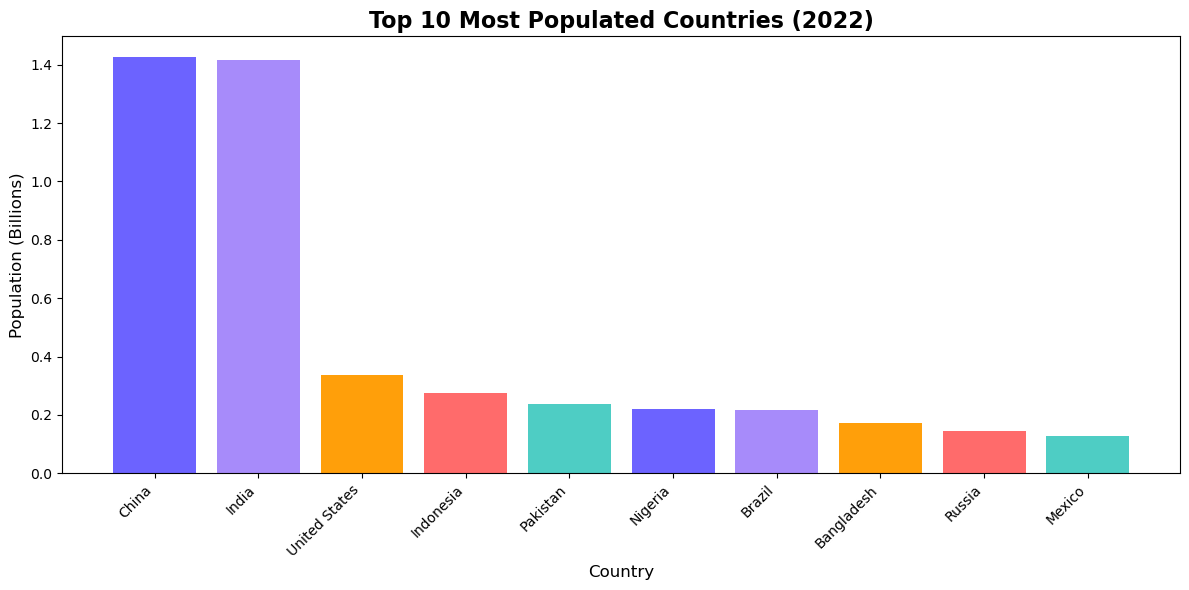

In [8]:
# Bar chart of top 10 most populated countries
plt.figure(figsize=(12, 6))
colors = ['#6c63ff', '#a78bfa', '#ff9f0a', '#ff6b6b', '#4ecdc4', 
          '#6c63ff', '#a78bfa', '#ff9f0a', '#ff6b6b', '#4ecdc4']

plt.bar(top10['Country/Territory'], top10['2022 Population'] / 1e9, color=colors)
plt.title('Top 10 Most Populated Countries (2022)', fontsize=16, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Population (Billions)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

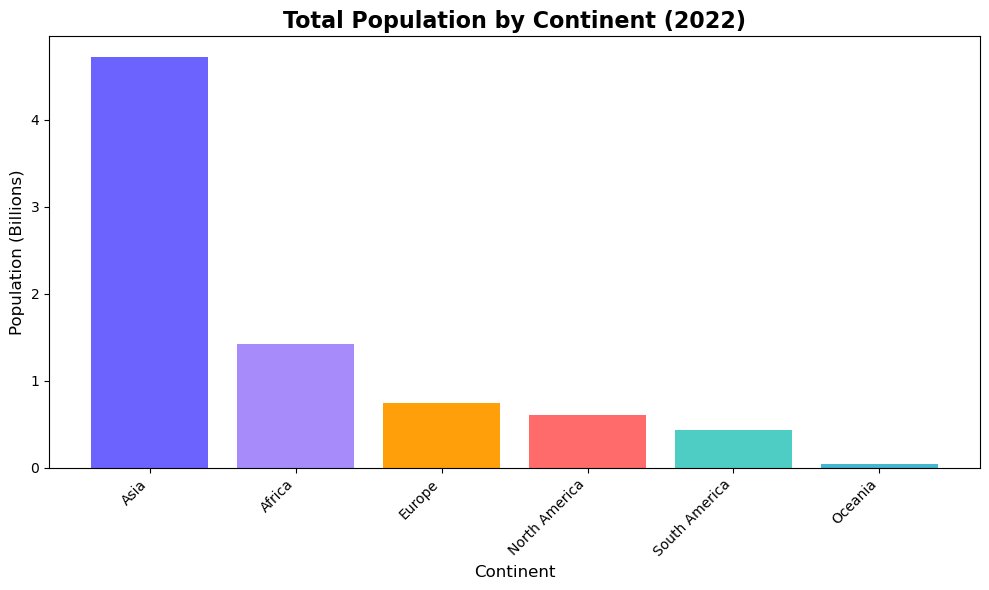

In [7]:
# Population by continent
continent_pop = df.groupby('Continent')['2022 Population'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(continent_pop.index, continent_pop.values / 1e9, 
        color=['#6c63ff', '#a78bfa', '#ff9f0a', '#ff6b6b', '#4ecdc4', '#45b7d1'])
plt.title('Total Population by Continent (2022)', fontsize=16, fontweight='bold')
plt.xlabel('Continent', fontsize=12)
plt.ylabel('Population (Billions)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# Final statistics
print("=== WORLD POPULATION STATISTICS (2022) ===")
print()
print(f"Total World Population: {df['2022 Population'].sum() / 1e9:.2f} Billion")
print(f"Number of Countries: {len(df)}")
print()
print(f"Most Populated Country: {df.loc[df['2022 Population'].idxmax(), 'Country/Territory']}")
print(f"Least Populated Country: {df.loc[df['2022 Population'].idxmin(), 'Country/Territory']}")
print()
print(f"Fastest Growing Country: {df.loc[df['Growth Rate'].idxmax(), 'Country/Territory']}")
print(f"Most Densely Populated: {df.loc[df['Density (per km²)'].idxmax(), 'Country/Territory']}")

=== WORLD POPULATION STATISTICS (2022) ===

Total World Population: 7.97 Billion
Number of Countries: 234

Most Populated Country: China
Least Populated Country: Vatican City

Fastest Growing Country: Moldova
Most Densely Populated: Macau


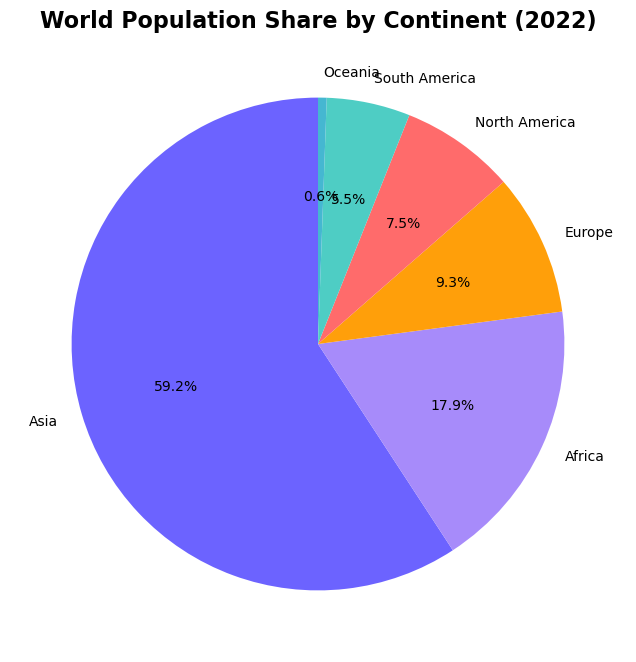

In [12]:
# Pie chart of population by continent
plt.figure(figsize=(8, 8))
plt.pie(
    continent_pop.values,
    labels=continent_pop.index,
    autopct='%1.1f%%',
    colors=['#6c63ff', '#a78bfa', '#ff9f0a', '#ff6b6b', '#4ecdc4', '#45b7d1'],
    startangle=90
)
plt.title('World Population Share by Continent (2022)', fontsize=16, fontweight='bold')
plt.show()